In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self.grad = 0
        self._backward = lambda : None
        self._op = _op
        self.label = label


    def __repr__(self):
        return f"value(data={self.data})"
    
    def __rmul__(self, other):
        return self * other
    
    def __radd__(self, other):
        return self + other
    
    def __rsub__(self, other):
        return other + (-self)
    
    def __neg__(self):
        return self * -1
    
    def __truediv__(self, other):
        return self * other**-1

    def __sub__(self, other):
        return self + (-other)
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1 * out.grad
            other.grad += 1 * out.grad
        out._backward = _backward
        return out

    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad 
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int,float)), "Only supporting int and float for power"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) *out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    
    def backward(self):
        # topological sort
        topo = []
        visited = set()
        def build(v):
            if v not in visited:
                visited.add(v)
                
                for child in v._prev:
                    build(child)
                
                topo.append(v)
        
        build(self)
        # initialize to 0
        for node in topo:
            node.grad = 0.0
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
            
    


In [37]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})

    nodes, edges = trace(root)
    
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label= f" {n.label} | {n.data:.4f} | {n.grad:.4f}", shape="rect" )

        if n._op:
            dot.node(name= uid + n._op, label= n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+ n2._op)
    
    return dot

In [67]:
# inputs x1,x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1+x2w2 ; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

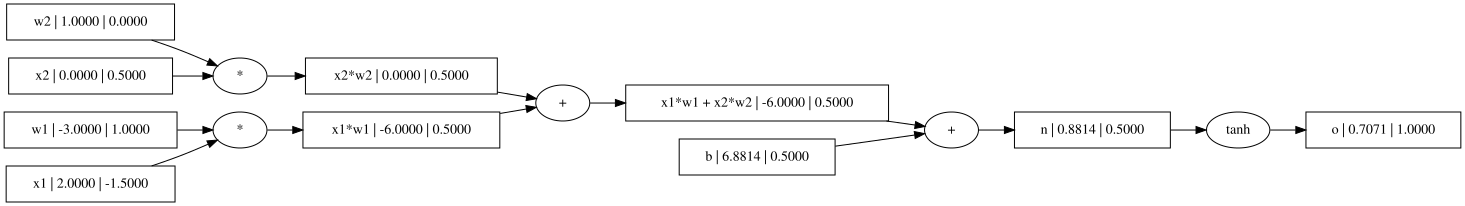

In [71]:
draw_dot(o)

In [ ]:
# manual backward
o.grad = 1
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()

In [ ]:
# inputs x1,x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1+x2w2 ; x1w1x2w2.label = 'x1*w1 + x2*w2'
x = x1w1x2w2 + b; n.label = 'x'
e = (2*x).exp(); e.label = 'e'
t = (e - 1) / (e + 1); t.label = 't'
t.backward()

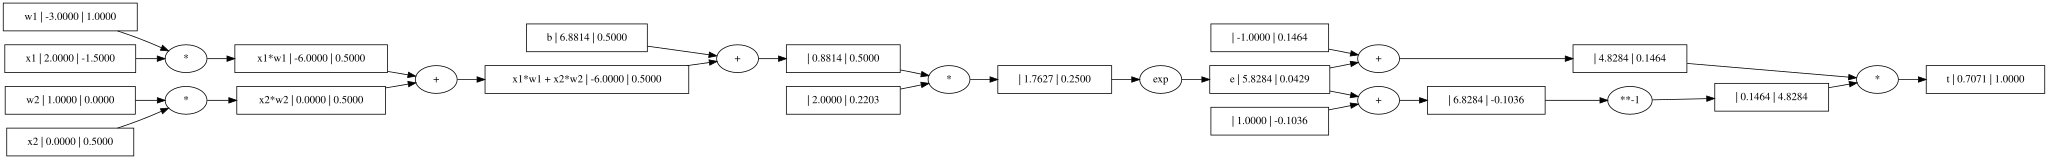

In [109]:

draw_dot(t)

In [81]:
# topological sort
topo = []
visited = set()
def build(v):
    if v not in visited:
        visited.add(n)

        for child in v._prev:
            build(child)
        topo.append(v)
    return topo

In [89]:
c.backward()